# PBMC68k 前処理 - ODE制約対応版

このノートブックは、ODE制約が正しく適用されるように前処理を行います。

## 主な変更点:
- HVGでn_top_genesを指定しない
- 遺伝子名の変換対応
- エッジファイルとの重複確認

In [7]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
# scDiffusionプロジェクトのパスを追加
sys.path.append('/home/suzuki/Projects/scDiffusion')

print("必要なライブラリを読み込み完了")

必要なライブラリを読み込み完了


In [ ]:
# cell_train_soft20251014_hvg1024.pyの前処理部分を実行
# ただし、HVGのn_top_genesは指定しない

# データの読み込み
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k.h5ad')
print(f"元データサイズ: {adata.shape}")

# 基本的なフィルタリング
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
adata.var_names_make_unique()
print(f"フィルタリング後: {adata.shape}")

# 正規化
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("正規化完了")

元データサイズ: (68579, 32738)
フィルタリング後: (68579, 17789)
正規化完了


In [4]:
# HVG を計算（例として n_top_genes を指定しない or 指定する）
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=None,            # もしくは例えば 3000
    # flavor='seurat_v3',          # ランキング列を得たいならこのフレーバーを使うと良い
    subset=False,
    inplace=True
)

# HVG統計を確認
n_hvg = adata.var['highly_variable'].sum()
print(f"検出されたHVG数: {n_hvg}")
print(f"総遺伝子数: {adata.n_vars}")
print(f"HVG割合: {n_hvg/adata.n_vars*100:.2f}%")

検出されたHVG数: 1488
総遺伝子数: 17789
HVG割合: 8.36%


In [45]:
import pandas as pd

# TSVファイル読み込み（パスを適宜修正）
edge_file = "/home/suzuki/Projects/scDiffusion/external_data/tf_target_edges.tsv"
edges_df = pd.read_csv(edge_file, sep='\t')

# 遺伝子名から重複を外した set（必要に応じて）
from_genes = set(edges_df['from'].unique())
to_genes   = set(edges_df['to'].unique())

# 全エッジを保持する DataFrame
# 必要なら ‘from’, ‘to’列以外を drop する
edges_df_simple = edges_df[['from', 'to']].copy()

# 出力
print(edges_df_simple.head())
print(f"総エッジ数: {len(edges_df_simple)}")

# 変数として戻しておく
edges = edges_df_simple
# 重複を削除
edges = edges.drop_duplicates().reset_index(drop=True)

   from       to
0  KLF2   DLGAP1
1  KLF2     DTNB
2  KLF2  BHLHE40
3  KLF2  RPS6KA1
4  KLF2      PXN
総エッジ数: 5870450


In [46]:
# 選出された HVG 数を確認
print("HVG 選出数:", adata.var['highly_variable'].sum())

# エッジファイルとの遺伝子名集合を取得済みという前提
from_genes = set(edges_df['from'].unique())
to_genes = set(edges_df['to'].unique())
all_edge_genes = from_genes.union(to_genes)

HVG 選出数: 1488


In [48]:
adata

AnnData object with n_obs × n_vars = 68579 × 17789
    obs: 'TSNE.1', 'TSNE.2', 'celltype', 'n_genes'
    var: 'gene_id', 'gene_name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

全遺伝子数: 17789
エッジに存在する遺伝子数: 13659
エッジに存在しない遺伝子数: 4109


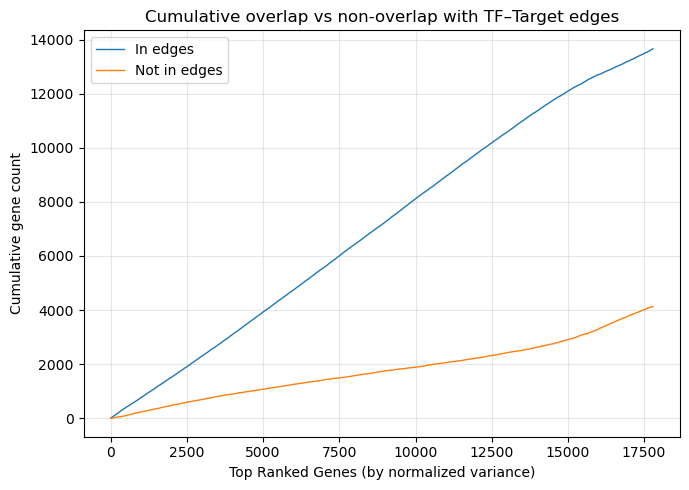

In [51]:
# adata.var の中で対象となる遺伝子（adata に存在し、エッジファイルにも載っている）を取得
genes_in_data = set(adata.var["gene_name"])
genes_with_edges = genes_in_data.intersection(all_edge_genes)
print(f"データ中かつエッジファイルに載ってる遺伝子数: {len(genes_with_edges)}")
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 1. normalized variance 列の選択
# ================================
if 'variances_norm' in adata.var.columns:
    norm_var_col = 'variances_norm'
elif 'dispersions_norm' in adata.var.columns:
    norm_var_col = 'dispersions_norm'
else:
    raise KeyError("normalized variance／dispersion 列が見つかりません")

# ================================
# 2. 遺伝子名（gene_name）を使ってランキング作成
# ================================
if "gene_name" in adata.var.columns:
    gene_id_col = "gene_name"
else:
    gene_id_col = adata.var.index.name if adata.var.index.name else "index"
    adata.var[gene_id_col] = adata.var.index

var_rank_df = adata.var[[gene_id_col, norm_var_col]].copy()
var_rank_df = var_rank_df.sort_values(by=norm_var_col, ascending=False).reset_index(drop=True)
var_rank_df["rank"] = np.arange(1, var_rank_df.shape[0] + 1)

# ================================
# 3. エッジ遺伝子集合
# ================================
edge_genes = set(all_edge_genes)

gene_list = var_rank_df[gene_id_col].tolist()
cumulative_counts = []
cumulative_nonedge = []

# ================================
# 4. 各順位ごとに「含まれる／含まれない」数を累積
# ================================
for i in range(1, len(gene_list) + 1):
    top_genes = set(gene_list[:i])
    overlap_count = len(top_genes.intersection(edge_genes))
    nonoverlap_count = i - overlap_count  # 全体iから重複を引いた残り
    cumulative_counts.append(overlap_count)
    cumulative_nonedge.append(nonoverlap_count)

# ================================
# 5. 検証出力
# ================================
print(f"全遺伝子数: {len(gene_list)}")
print(f"エッジに存在する遺伝子数: {len(edge_genes.intersection(set(gene_list)))}")
print(f"エッジに存在しない遺伝子数: {len(set(gene_list) - edge_genes)}")

# ================================
# 6. グラフ表示
# ================================
plt.figure(figsize=(7,5))
plt.plot(var_rank_df["rank"].values, cumulative_counts, label="In edges", color="tab:blue", lw=1)
plt.plot(var_rank_df["rank"].values, cumulative_nonedge, label="Not in edges", color="tab:orange", lw=1)
plt.xlabel("Top Ranked Genes (by normalized variance)")
plt.ylabel("Cumulative gene count")
plt.title("Cumulative overlap vs non-overlap with TF–Target edges")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
